# TiTiler CMR configuration: Harmonized Landsat Sentinel 2 (HLS)

This notebook analyzes the performance benchmarks for the Harmonized Landsat Sentinel (HLS) tiler endpoint in titiler-cmr. The benchmarks measure how effectively the API handles tile requests across varying conditions.

## Background

The Harmonized Landsat Sentinel (HLS) dataset provides surface reflectance data by combining observations from the Operational Land Imager (OLI) and Multi-Spectral Instrument (MSI) aboard the Landsat 8/9 and Sentinel-2 satellites, respectively. This data is processed to enable time series analyses.

Two HLS collections are available in CMR:
- **HLSL30**: Harmonized Landsat 8/9 data (30m resolution)
- **HLSS30**: Harmonized Sentinel-2 data (30m resolution)

These collections have specific characteristics that impact the performance of tile rendering:
1. Each granule covers one MGRS (Military Grid Reference System) tile
2. The data is stored as separate files per band (e.g., B01, B02, etc.)
3. Temporal coverage is not uniform across the globe

## Performance Factors

Several factors affect tiling performance:
1. **Zoom level**: Lower zoom levels require rendering pixels from more assets
2. **Temporal range**: Larger time ranges require searching through and rendering more granules
3. **Band combination**: More bands require more files to be accessed and processed
3. **Collection choice**: HLSS30 has a more frequent revisit rate than HLSL30


In [1]:
import json

import httpx
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from folium import Map, TileLayer

# Load the benchmark data
with open("../../benchmark.json", "r") as f:
    benchmark_data = json.load(f)

# Set style for plots
plt.style.use("ggplot")
sns.set_palette("colorblind")

In [2]:
results = []
for benchmark in benchmark_data["benchmarks"]:
    # Only include results from the hls-tiles group
    if benchmark["group"] == "hls-tiles":
        row = {
            "name": benchmark["name"],
            "collection": benchmark["extra_info"]["collection"],
            "zoom": benchmark["extra_info"]["zoom"],
            "interval_days": benchmark["extra_info"]["interval_days"],
            "band_count": benchmark["extra_info"]["band_count"],
            "mean_time": benchmark["stats"]["mean"],  # Mean execution time in seconds
            "success_rate": benchmark["extra_info"]["success_rate"],
            "avg_response_time": benchmark["extra_info"]["avg_response_time"],
            "avg_response_size": benchmark["extra_info"]["avg_response_size"],
        }
        results.append(row)

df = pd.DataFrame(results)

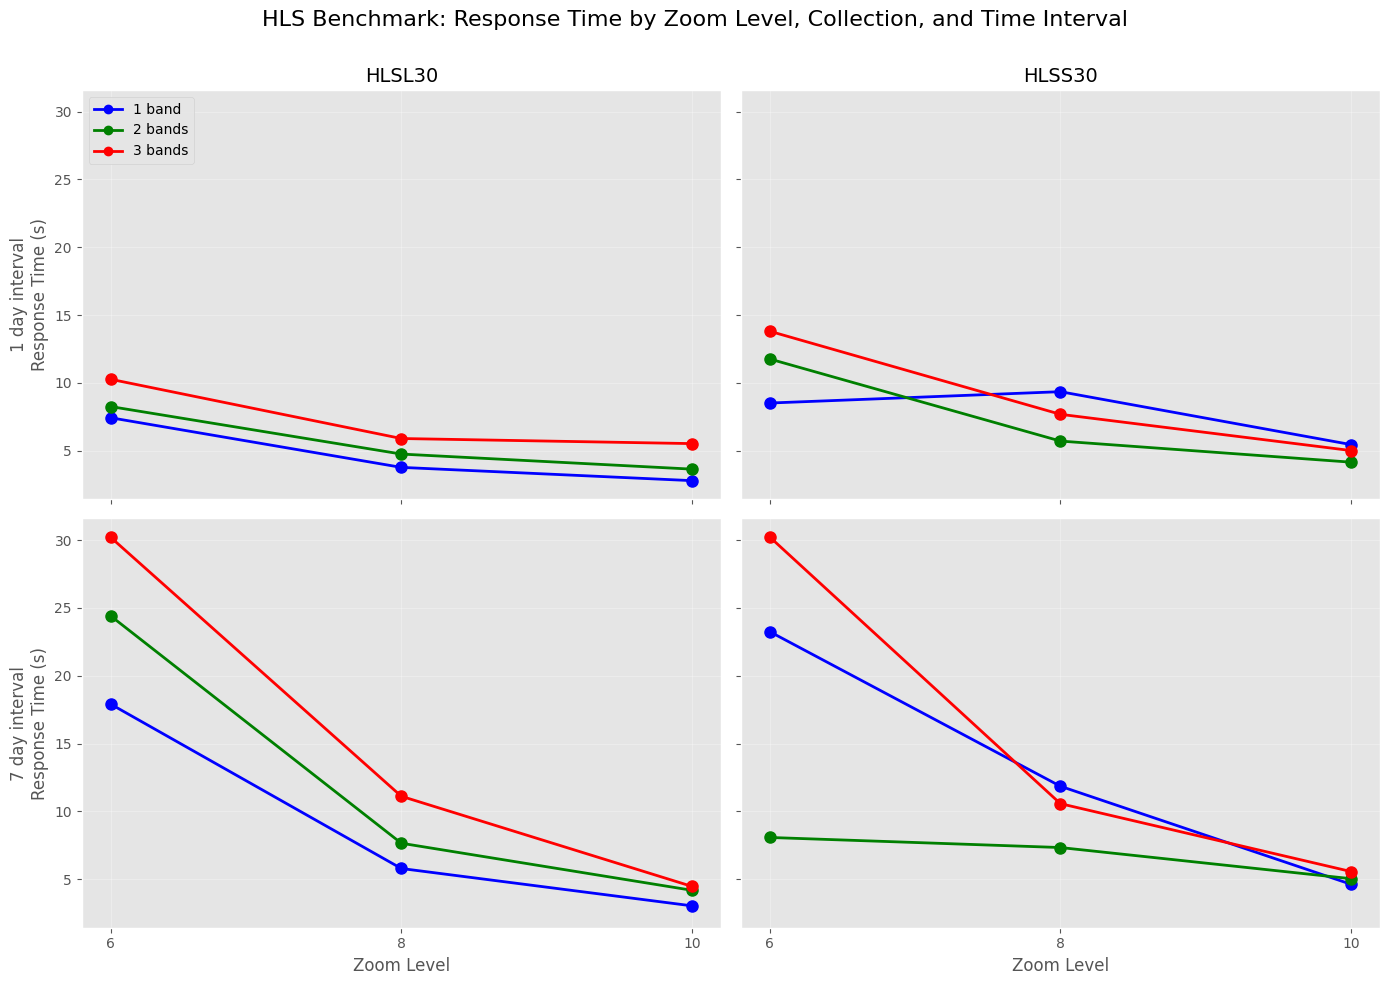

In [4]:
# Get unique values for facets
collections = df["collection"].unique()
intervals = df["interval_days"].unique()

# Create a faceted chart with collections as columns and time intervals as rows
fig, axes = plt.subplots(
    nrows=len(intervals),
    ncols=len(collections),
    figsize=(14, 10),
    sharex=True,
    sharey=True,
)

# Band colors
band_colors = {1: "blue", 2: "green", 3: "red"}

# Create each facet
for i, interval in enumerate(sorted(intervals)):
    for j, collection in enumerate(sorted(collections)):
        ax = axes[i, j]

        # Filter data for this facet
        facet_data = df[
            (df["collection"] == collection) & (df["interval_days"] == interval)
        ]

        # Plot each band count as a separate line
        for band_count, band_data in facet_data.groupby("band_count"):
            # Sort by zoom level to ensure proper line connections
            band_data = band_data.sort_values("zoom")

            ax.plot(
                band_data["zoom"],
                band_data["mean_time"],
                marker="o",
                markersize=8,
                color=band_colors[band_count],
                linewidth=2,
                label=f"{band_count} bands",
            )

        # Add facet title only on the first row and column
        if i == 0:
            ax.set_title(collection, fontsize=14)
        if j == 0:
            ax.set_ylabel(f"{interval} day interval\nResponse Time (s)", fontsize=12)

        # Add x-label only on the bottom row
        if i == len(intervals) - 1:
            ax.set_xlabel("Zoom Level", fontsize=12)

        # Set x-ticks to show the actual zoom levels
        ax.set_xticks([6, 8, 10])

        # Add grid
        ax.grid(True, alpha=0.3)

        # Only add legend to the first plot
        if i == 0 and j == 0:
            # Create legend for band counts
            band_handles = [
                plt.Line2D(
                    [0],
                    [0],
                    color=band_colors[b],
                    label=f"{b} band{'s' if b > 1 else ''}",
                    marker="o",
                    markersize=6,
                    linewidth=2,
                )
                for b in sorted(band_colors.keys())
            ]
            ax.legend(handles=band_handles, loc="upper left")

# Add an overall title
fig.suptitle(
    "HLS Benchmark: Response Time by Zoom Level, Collection, and Time Interval",
    fontsize=16,
    y=0.98,
)

# Adjust layout
plt.tight_layout()
fig.subplots_adjust(top=0.9)

## Performance Limitations and Guidance

Based on the benchmark analysis, here are some recommendations for using the HLS tile endpoint effectively:

### Zoom Levels
* **Recommended zoom range**: Zoom levels 7-10 generally provide the best balance of performance and detail
* **Success rates decrease** significantly at zoom levels above 10
* **Response times increase** with higher zoom levels

### Time Intervals
* **Shorter time intervals** (1-3 days) generally perform better
* As interval length increases, consider reducing the zoom level to maintain performance
* For intervals longer than 7 days, you might need to reduce expectations for success rate

### Band Combinations
* **Single band queries** perform best for high success rates
* True color (RGB) combinations require more processing time but are viable at lower zoom levels
* For RGB rendering, consider using zoom levels 7-9 for the best performance

### Collection Differences
* **HLSL30 (Landsat)** tends to have slightly faster response times but may have lower success rates in some cases
* **HLSS30 (Sentinel-2)** generally has better coverage (higher success rates) but slightly longer processing times
* For applications requiring high success rates, HLSS30 may be preferred

### Best Practices
* Start with conservative parameters (lower zoom, shorter time interval) and adjust as needed
* For web mapping applications, implement appropriate error handling for failed tiles
* Consider caching successful tiles for better user experience
* Limit the viewport size to reduce the number of concurrent tile requests

Remember that performance can vary based on the specific region and time period due to differences in data availability and coverage.

## Conclusion

The HLS tiles endpoint in titiler-cmr provides an effective way to access and visualize HLS data, with performance that varies based on several key factors:

1. **Zoom level** has the most significant impact on both success rate and response time
2. **Time interval** affects the number of granules that need to be processed and can impact success rates
3. **Band combinations** increase processing requirements, especially when moving from single bands to RGB
4. **Collection choice** between HLSL30 and HLSS30 offers different trade-offs in coverage vs. performance

By understanding these performance characteristics, users can optimize their requests to achieve the best balance of detail, coverage, and responsiveness for their specific use cases.

For most web mapping applications, zoom levels 7-10 with time intervals of 1-5 days provide the best overall performance. As the temporal range increases, consider reducing the zoom level to maintain good performance.

In [9]:
titiler_endpoint = "https://dev-titiler-cmr.delta-backend.com"

concept_ids = {
    "HLSL30": "C2021957657-LPCLOUD",
    "HLSS30": "C2021957295-LPCLOUD",
}

r = httpx.get(
    f"{titiler_endpoint}/WebMercatorQuad/tilejson.json",
    params=(
        ("concept_id", concept_ids["HLSL30"]),
        # Datetime in form of `start_date/end_date`
        ("datetime", "2025-03-10T00:00:00Z/2025-03-10T23:59:59Z"),
        # We know that the HLS collection dataset is stored as File per Band
        # so we need to pass a `band_regex` option to assign `bands` to each URL
        ("bands_regex", "B[0-9][0-9]"),
        # titiler-cmr can work with both Zarr and COG dataset
        # but we need to tell the endpoints in advance which backend
        # to use
        ("backend", "rasterio"),
        # True Color Image B04,B03,B02
        ("bands", "B04"),
        ("bands", "B03"),
        ("bands", "B02"),
        # The data is in type of Uint16 so we need to apply some
        # rescaling/color_formula in order to create PNGs
        ("color_formula", "Gamma RGB 3.5 Saturation 1.7 Sigmoidal RGB 15 0.35"),
        # We need to set min/max zoom because we don't want to use lowerzoom level (e.g 0)
        # which will results in useless large scale query
        ("minzoom", 6),
        ("maxzoom", 13),
    ),
).json()

m = Map(location=(46.7653, -91.0321), zoom_start=r["minzoom"] + 1)


TileLayer(
    tiles=r["tiles"][0],
    opacity=1,
    attr="NASA",
).add_to(m)

m